# Lab 9 Report: 
## Final Project Codebase

## Project Title: Facial Recognition

### Group Members: Javier Guapilla Diaz & McKinley Nhi Seecof Quevedo

--------------------

## Imports

In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import os
from PIL import Image # For easy manipulation of images and stuff
from PIL import ImageEnhance
import random
d = torch.device('cuda')

In [2]:
torch.cuda.empty_cache()

## Prepare Data

Loading In Data

In [3]:
# from sklearn.model_selection import train_test_split

# folders = ["train", "test"]
# emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
# path = r"C:\Users\jguap\OneDrive\Desktop\spr26\final_data\data\\"

# IMG_SIZE = (48, 48)

# all_data = []
# all_labels = []

# # loading data - no more branching, just collect everything
# for f in folders:
#     for i in range(len(emotions)):
#         e = emotions[i]
#         curr_path = os.path.join(path, f, e)
#         for filename in os.listdir(curr_path):
#             curr_image_path = os.path.join(curr_path, filename)
#             curr_image = Image.open(curr_image_path).convert("L")
#             curr_image = curr_image.resize(IMG_SIZE)

#             all_data.append(np.array(curr_image))
#             all_labels.append(i)

# # split before augmentation
# all_data = np.array(all_data)
# all_labels = np.array(all_labels)

# X_train_raw, test_data, y_train_raw, test_labels = train_test_split(
#     all_data, all_labels, test_size=0.2, stratify=all_labels, random_state=42
# )

# # augmentation only on training portion
# train_data = []
# train_labels = []

# for img, label in zip(X_train_raw, y_train_raw):
#     curr_image = Image.fromarray(img)
    
#     # original
#     train_data.append(np.array(curr_image))
#     train_labels.append(label)
#     # flip
#     train_data.append(np.array(curr_image.transpose(Image.FLIP_LEFT_RIGHT)))
#     train_labels.append(label)
#     # rotation
#     angle = random.uniform(-10, 10)
#     train_data.append(np.array(curr_image.rotate(angle)))
#     train_labels.append(label)
#     # brightness
#     factor = random.uniform(0.8, 1.2)
#     train_data.append(np.array(ImageEnhance.Brightness(curr_image).enhance(factor)))
#     train_labels.append(label)

# # converting to np arrays
# train_data = np.array(train_data).reshape(-1, 1, 48, 48)
# test_data = np.array(test_data).reshape(-1, 1, 48, 48)
# train_labels = np.array(train_labels)
# test_labels = np.array(test_labels)
from sklearn.model_selection import train_test_split

folders = ["train", "test"]
emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
path = r"C:\Users\AlpacaAdmin\Documents\UW\Spring26\final-proj\phys417final\FER-2013"
IMG_SIZE = (48, 48)

all_data = []
all_labels = []

# loading data
for f in folders:
    for i in range(len(emotions)):
        e = emotions[i]
        curr_path = os.path.join(path, f, e)
        for filename in os.listdir(curr_path):
            curr_image_path = os.path.join(curr_path, filename)
            curr_image = Image.open(curr_image_path).convert("L")
            curr_image = curr_image.resize(IMG_SIZE)
            all_data.append(np.array(curr_image))
            all_labels.append(i)

all_data = np.array(all_data)
all_labels = np.array(all_labels)

# step 1: train/test split (raw)
X_train_raw, test_data, y_train_raw, test_labels = train_test_split(
    all_data, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# step 2: train/val split (raw, before augmentation)
X_train_raw, X_val_raw, y_train_raw, validation_labels = train_test_split(
    X_train_raw, y_train_raw, test_size=0.1, stratify=y_train_raw, random_state=2
)

# step 3: augment only training portion
train_data = []
train_labels = []

for img, label in zip(X_train_raw, y_train_raw):
    curr_image = Image.fromarray(img)
    train_data.append(np.array(curr_image))
    train_labels.append(label)
    train_data.append(np.array(curr_image.transpose(Image.FLIP_LEFT_RIGHT)))
    train_labels.append(label)
    angle = random.uniform(-10, 10)
    train_data.append(np.array(curr_image.rotate(angle)))
    train_labels.append(label)
    factor = random.uniform(0.8, 1.2)
    train_data.append(np.array(ImageEnhance.Brightness(curr_image).enhance(factor)))
    train_labels.append(label)

train_data = np.array(train_data)
train_labels = np.array(train_labels)
validation_data = X_val_raw  # no augmentation

train_total = len(train_data)

In [4]:
print(train_data.shape)
print(test_data.shape)
print(validation_data.shape)

(103352, 48, 48)
(7178, 48, 48)
(2871, 48, 48)


Reshaping

In [5]:
train_data = np.reshape(train_data, (train_total, (48*48)))# YOUR CODE HERE
test_data = np.reshape(test_data, (len(test_data), (48*48)))# YOUR CODE HERE
validation_data = np.reshape(validation_data, (len(validation_data), 48*48))

ValidationTraining $\rightarrow$ Training (90\%) & Validation (10\%)

In [ ]:
# # Take the first 1000 training features and targets as validation set

# spl = train_test_split(train_data, 
#                        train_labels, 
#                        test_size=0.1,random_state=2)
# # ^^ Splits data in following order: train feature, validation features, train targets, validation targets

# validation_data = spl[1]
# validation_labels = spl[3]

# # Take the remaining 9000 training features and targets as training set 
# train_data = spl[0]
# train_labels = spl[2]

# # Checking sizes to make sure I split correctly
# print(validation_data.shape, validation_labels.shape)
# print(train_data.shape, train_labels.shape)

Scaling

In [ ]:
# Defining scaling function
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# # Scale the dataset according to standard scaling
# train_data = scaler.fit_transform(train_data) # Fitting to and scaling training data 
# validation_data = scaler.transform(validation_data)
# test_data = scaler.transform(test_data)# scaling testing data

In [6]:
train_data = train_data.astype(np.float32) / 255.0
validation_data = validation_data.astype(np.float32) / 255.0
test_data = test_data.astype(np.float32) / 255.0

In [7]:
# Reshape train/validation/test sets to conform to PyTorch's (N, Channels, Height, Width) standard for CNNs

train_features = train_data.reshape(-1, 1, 48, 48) # Going back to 48X48 images for CNN
validation_features = validation_data.reshape(-1, 1, 48, 48) # ^^
test_features = test_data.reshape(-1,1,48,48) # ^^

# Checking the shape
print(train_features.shape)
print(validation_features.shape)
print(test_features.shape)

(103352, 1, 48, 48)
(2871, 1, 48, 48)
(7178, 1, 48, 48)


Converting to Tensors

In [8]:
# Make them into tensors
train_inputs = torch.from_numpy(train_features).float() # converting to floats
train_targets = torch.from_numpy(train_labels).long() # converting to 64-bit integer

validation_inputs = torch.from_numpy(validation_features).float()#.to(d) # converting to floats
validation_targets = torch.from_numpy(validation_labels).long()#.to(d) # converting to 64-bit integer

testing_inputs = torch.from_numpy(test_features).float()#.to(d) # converting to floats
testing_targets = torch.from_numpy(test_labels).long()#.to(d) # converting to 64-bit integer

# NOTE: Each of the tensors above used .to(d) which takes out tensors and puts them "in" my computers gpu
#       I did this to speed up computation and to actually use cuda.

## Define Model

In [9]:
#here's the other model: 
import torch
import torch.nn as nn
import torch.nn.functional as F

class FacialExpressionCNN(nn.Module):
    def __init__(self):
        super(FacialExpressionCNN, self).__init__()
        
        # Layer 1: Conv2D (32 filters, same padding to keep 48x48)
        # Input assumed to be 1 channel (grayscale) or 3 based on augmentation notes
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        
        # Layer 2: Conv2D (64 filters, same padding)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 3: Conv2D (64 filters, same padding)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 4: MaxPooling (Reduces 48x48 to 9x9 based on Table 1)
        # Note: A standard pool wouldn't jump 48->9. This implies a kernel ~5x5.
        self.pool1 = nn.MaxPool2d(kernel_size=5, stride=5) 
        
        # Layer 5: Dropout
        self.dropout1 = nn.Dropout(0.25)
        
        # Layer 6: Conv2D (128 filters, 9x9 -> 7x7)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        
        # Layer 7: Conv2D (128 filters, 7x7 -> 5x5)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3)
        
        # Layer 8: MaxPooling (5x5 -> 1x1)
        self.pool2 = nn.MaxPool2d(kernel_size=5)
        
        # Layer 9: Dropout
        self.dropout2 = nn.Dropout(0.25)
        
        # Layer 10: Flatten (Done in forward pass)
        
        # Layer 11: Dense (500 units)
        self.fc1 = nn.Linear(128 * 1 * 1, 500)
        
        # Layer 12: Dropout
        self.dropout3 = nn.Dropout(0.5)
        
        # Layer 13: Dense (7 units for facial expressions)
        self.fc2 = nn.Linear(500, 7)

    def forward(self, x):
        # Convolutional Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Convolutional Block 2
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Flattening
        x = torch.flatten(x, 1)
        
        # Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        
        # Final Layer (Softmax is often handled by CrossEntropyLoss in PyTorch)
        x = self.fc2(x)
        return x

## Define Hyperparameters

In [11]:
# Fix the random seed so that model performance is reproducible
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader #added dataloader so that random data is batched
torch.manual_seed(55)

# Initializing model
model = FacialExpressionCNN()
model = model.to(d) # Bc I wanted to use my gpu, also "sent" model to GPU to work w/ tensors from before.

# Defining learning rate, epoch and batchsize for mini-batch gradient
learning_rate = 0.001
epochs = 60 #20 #30

## Mini-batch set up, splitting up the tensors from before
batchsize = 64
# train_batches_features = torch.split(train_inputs, batchsize)
# train_batches_targets = torch.split(train_targets, batchsize)
# batch_split_num = len(train_batches_features)
train_dataset = TensorDataset(train_inputs, train_targets)
val_dataset = TensorDataset(validation_inputs, validation_targets)
# NOTE: num_workers is for threads, and pin_memory is for locking memory
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True, pin_memory=True, num_workers=2)
validation_loader = DataLoader(val_dataset,batch_size=batchsize, shuffle=False,  pin_memory=True, num_workers=2)

# Define loss function and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

model # just to check the model I am using

FacialExpressionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=128, out_features=500, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=500, out_features=7, bias=True)
)

## Identify Tracked Values

In [12]:
# Placeholders for training loss and validation accuracy during training
train_loss_list = []
validation_loss_list = []
validation_accuracy_list = []

## Train Model

In [13]:
import tqdm #For loading bar

# Actual training of the modeL:
for epoch in tqdm.trange(epochs):
    
    model.train() # I was told in a previous class doing this is good practice.
    e_loss = 0.0 # the average loss for this epoch bc I use mini-batch
    
    # Working w the batches
    # for k in range(batch_split_num):
    for features, targets in train_loader:
        # set up:
        # using batch k to train on
        # features_k = train_batches_features[k]
        # targets_k = train_batches_targets[k]
        features_k = features.to(d)
        targets_k = targets.to(d)

        # training
        optimizer.zero_grad()
        train_batch_outputs = model(features_k)
        loss = loss_func(train_batch_outputs, targets_k)
        e_loss += loss.item()

        # moving the optimizer along
        loss.backward()
        optimizer.step()
    
    # getting the avg loss over the batches for this epoch
    # epoch_avg_loss = e_loss / batch_split_num
    epoch_avg_loss = e_loss / len(train_loader)
    train_loss_list.append(epoch_avg_loss)

    # Compute Validation Accuracy ----------------------------------------------------------------------
    # model.eval() # Once again, I was told putting the model explicitly into eval mode was good practice
    # with torch.no_grad(): # Telling PyTorch we aren't passing inputs to network for training purpose
        
    #     validation_outputs = model(validation_inputs) # Getting validation scores
    #     val_loss = loss_func(validation_outputs, validation_targets)
    #     validation_loss_list.append(val_loss.item())

    #     correct = (torch.argmax(validation_outputs, dim=1) == 
    #                validation_targets).type(torch.FloatTensor) # converting validation scores to labels and
    #                                                            # counting the # of correctly labeled samples
        
    #     validation_accuracy_list.append(correct.mean()) # converting # of samples correct to percentage
    #     scheduler.step(val_loss.item())
    model.eval()

    with torch.no_grad():

        total_val_loss = 0.0
        total_correct = 0
        total_samples = 0

        for features, targets in validation_loader:

            features = features.to(d)
            targets = targets.to(d)

            validation_outputs = model(features)

            loss = loss_func(validation_outputs, targets)
            total_val_loss += loss.item()

            predictions = torch.argmax(validation_outputs, dim=1)

            total_correct += (predictions == targets).sum().item()
            total_samples += targets.size(0)

        avg_val_loss = total_val_loss / len(validation_loader)
        val_accuracy = total_correct / total_samples

        validation_loss_list.append(avg_val_loss)
        validation_accuracy_list.append(val_accuracy)

        scheduler.step(avg_val_loss)


100%|██████████| 60/60 [55:35<00:00, 55.59s/it]


## Visualize & Evaluate Model

Validation

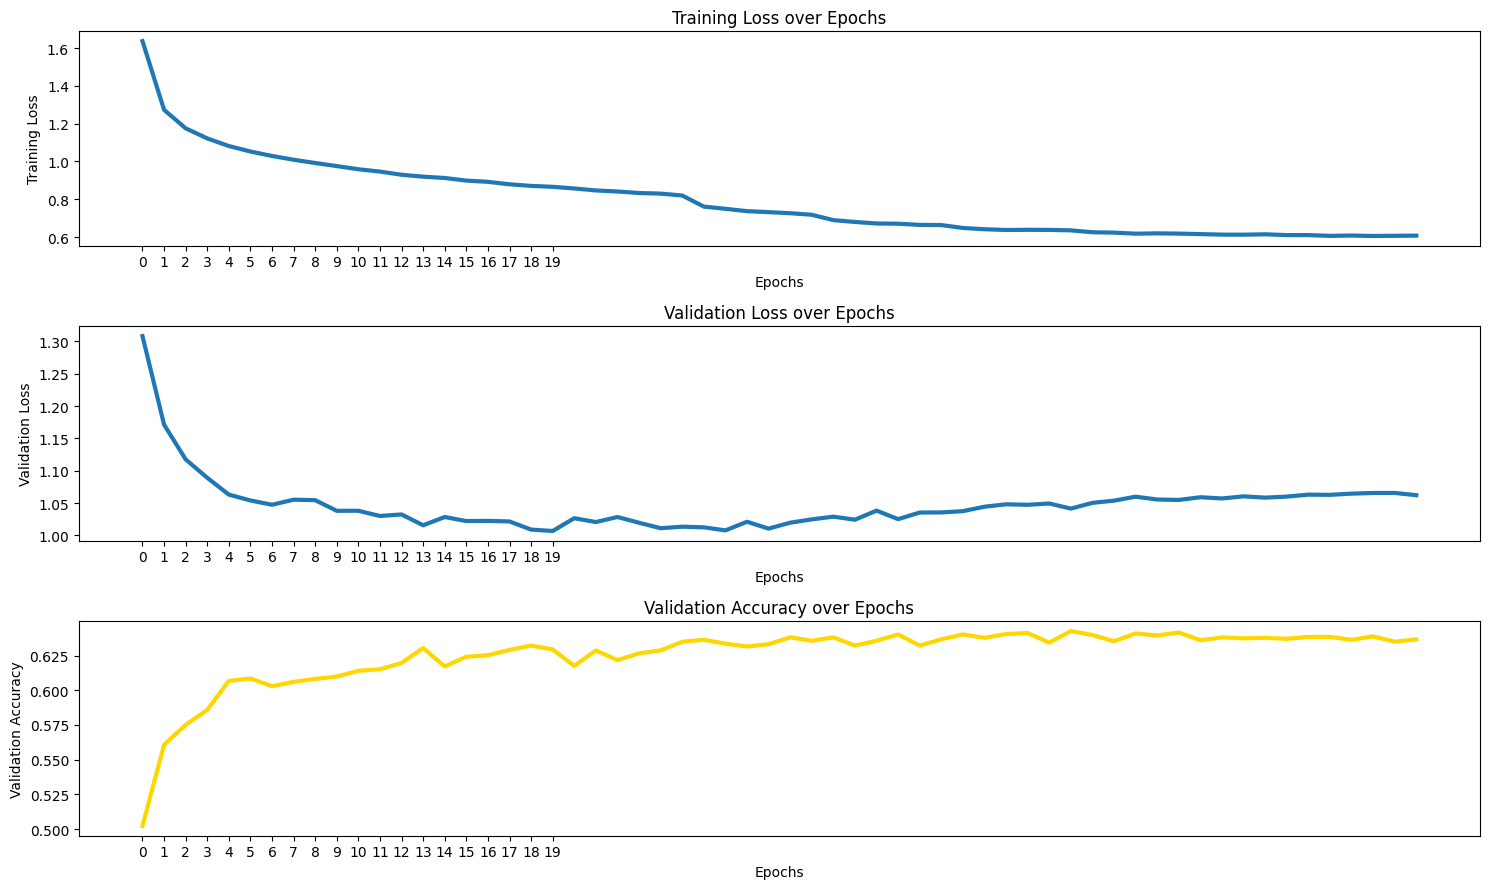

In [14]:
# Visualizing training loss and validation set accuracy
plt.figure(figsize = (15, 9))
xt = np.arange(20)

# Plot for Training Loss
plt.subplot(3, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.title("Training Loss over Epochs")
plt.ylabel("Training Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

plt.subplot(3, 1, 2)
plt.plot(validation_loss_list, linewidth = 3)
plt.title("Validation Loss over Epochs")
plt.ylabel("Validation Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

# Accuracy for validation set
plt.subplot(3, 1, 3)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.title("Validation Accuracy over Epochs")
plt.ylabel("Validation Accuracy")
plt.xlabel("Epochs")
plt.xticks(xt)
plt.tight_layout() #googled for overlapping labels
plt.show()

In [15]:
print(train_loss_list)
print(validation_loss_list)
print(validation_accuracy_list)

[1.6369442820179942, 1.2733232433950938, 1.1754355621780774, 1.122010321550694, 1.0816603985733293, 1.0526828804990456, 1.029187562258989, 1.009102160864201, 0.9918420901239472, 0.9756270610880188, 0.9587822151257895, 0.9464308296194756, 0.929662593414909, 0.9195496398967117, 0.9126226675399686, 0.8987929850908994, 0.8922164959435124, 0.8791818348800435, 0.870740915304367, 0.8659370615755442, 0.8571735730112152, 0.8466853000431238, 0.8411751123035656, 0.8330337210336337, 0.8298694155902685, 0.8198921286469274, 0.7612486123116023, 0.7495618354056273, 0.7371093535755441, 0.7319017232571593, 0.7261780878707721, 0.7179716439808116, 0.6896058702801035, 0.6799771393600264, 0.6719248071359037, 0.6706255095477444, 0.6645149396115412, 0.6634267020889849, 0.6481940033819653, 0.6413692417159538, 0.6375662778737744, 0.638336211184599, 0.6378636535845305, 0.6355492733764944, 0.6254356756298903, 0.6235280884124177, 0.6179188822076047, 0.6196636937166515, 0.6182397926924029, 0.6156960552321868, 0.612

Test

In [18]:
# Compute the testing accuracy
model.eval() # good practice again
with torch.no_grad():
    testing_inputs = testing_inputs.to(d)
    testing_targets = testing_targets.to(d)
    # testing model on test samples to get predicted values
    y_pred_test = model(testing_inputs) 
    
    # Use the same technique as above to compute the testing classification accuracy
    predicted_targets = torch.argmax(y_pred_test, dim=1)
    correct = (predicted_targets == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()*100) + '%') # printing the percentage

Testing Accuracy: 63.234882%


In [19]:
tt = testing_targets.cpu().numpy() #these are my true labels
pt = predicted_targets.cpu().numpy() # these are the predicted labels

# List of the different items we classified
c = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

print("--- Accuracy By Class ---\n")

# Looping over different classes/targets
for i in range(7):
    # Finding the accuracy:
    idx_k = np.where(tt==i) # finding true labels' indexs
    predicted_k = pt[idx_k] # using idx_k to find the predicted labels
    true_k = tt[idx_k] # getting the true labels
    percent_k = np.mean(predicted_k == true_k) # comparing true vs predicted

    # printing and formatting
    print("Accuracy of", c[i]+":", f"{percent_k*100:.2f}%")
    # ^ I used an f-string cuz it made formatting the percentage nicer

--- Accuracy By Class ---

Accuracy of angry: 53.38%
Accuracy of disgust: 44.95%
Accuracy of fear: 40.72%
Accuracy of happy: 82.87%
Accuracy of neutral: 63.39%
Accuracy of sad: 52.22%
Accuracy of surprise: 79.12%


In [20]:
# Saving the model so it can be loaded for use later
torch.save(model.state_dict(), "model.pth")

In [ ]:
import cv2
import time
from ultralytics import YOLO

# --- PyTorch Model Definition ---
class FacialExpressionCNN(nn.Module):
    def __init__(self):
        super(FacialExpressionCNN, self).__init__()
        
        # Layer 1: Conv2D (32 filters, same padding to keep 48x48)
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        
        # Layer 2: Conv2D (64 filters, same padding)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 3: Conv2D (64 filters, same padding)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 4: MaxPooling (Reduces 48x48 to 9x9)
        self.pool1 = nn.MaxPool2d(kernel_size=5, stride=5) 
        
        # Layer 5: Dropout
        self.dropout1 = nn.Dropout(0.25)
        
        # Layer 6: Conv2D (128 filters, 9x9 -> 7x7)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        
        # Layer 7: Conv2D (128 filters, 7x7 -> 5x5)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3)
        
        # Layer 8: MaxPooling (5x5 -> 1x1)
        self.pool2 = nn.MaxPool2d(kernel_size=5)
        
        # Layer 9: Dropout
        self.dropout2 = nn.Dropout(0.25)
        
        # Layer 10: Flatten (Done in forward pass)
        
        # Layer 11: Dense (500 units)
        self.fc1 = nn.Linear(128 * 1 * 1, 500)
        
        # Layer 12: Dropout
        self.dropout3 = nn.Dropout(0.5)
        
        # Layer 13: Dense (7 units for facial expressions)
        self.fc2 = nn.Linear(500, 7)

    def forward(self, x):
        # Convolutional Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Convolutional Block 2
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Flattening
        x = torch.flatten(x, 1)
        
        # Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        
        # Final Layer (Softmax is often handled by CrossEntropyLoss in PyTorch)
        x = self.fc2(x)
        return x

# --- Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
face_model = YOLO("yolov11n-face.pt")

emotion_model = FacialExpressionCNN().to(device)
emotion_model.load_state_dict(torch.load("model.pth", map_location=device))
emotion_model.eval()

emotion_dict = {0: "Angry", 1: "Disgusted", 2: "Fearful", 3: "Happy", 4: "Neutral", 5: "Sad", 6: "Surprised"}

def analyze_emotions():
    cap = cv2.VideoCapture(0) 
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        results = face_model(frame)

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])  
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

                # Pre-processing (OpenCV -> PyTorch Tensor)
                face = frame[y1:y2, x1:x2]
                if face.size == 0: continue
                face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
                face_resized = cv2.resize(face_gray, (48, 48))
                
                # Convert to Tensor: (Batch, Channel, Height, Width)
                face_tensor = torch.from_numpy(face_resized).float().to(device)
                face_tensor = face_tensor.unsqueeze(0).unsqueeze(0) / 255.0

                # Prediction
                with torch.no_grad():
                    output = emotion_model(face_tensor)
                    prob = F.softmax(output, dim=1)
                    confidence, pred_idx = torch.max(prob, 1)
                    
                    max_val = pred_idx.item()
                    emotion = emotion_dict[max_val]
                    conf_val = confidence.item()



                cv2.putText(frame, f"{emotion} ({conf_val:.2f})", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        cv2.imshow("PyTorch Emotion Monitor", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"): break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    analyze_emotions()